# Constraint Satisfaction Program

This is classic **Symbolic AI** where we solve problems based on rules.
There are three parts

- Variable (v): The things that need to be decided. For this particular problem I am deciding the regions on a map.

- Domains (D): The possible values for those variables (colors red, blue, green etc)

- Constraints (C): The rules that must follow. For example Adjacent regions cannot be the same color.


> I will use a special python library called ```python-constraint``` to define constraints.

But first, I need to visualise the map in grayscale ... using a special library called ```geopandas``` along with ```matplotlib```

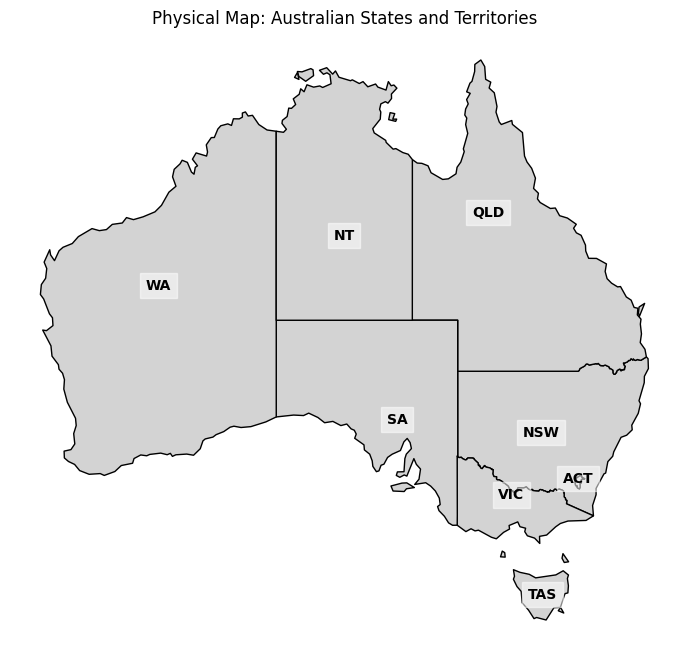

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Download the real geo-spatial data for Australian States
url = "https://raw.githubusercontent.com/tonywr71/GeoJson-Data/master/australian-states.json"
australia_states = gpd.read_file(url)

# 2. Plotting the map in grayscale
fig, ax = plt.subplots(figsize=(10, 8))
australia_states.plot(ax=ax, color='lightgray', edgecolor='black')

# 3. Add Labels for each region
# We use 'representative_point' to find a good spot for the text inside each shape
for idx, row in australia_states.iterrows():
    # The name column in this dataset is 'STATE_NAME' or 'STATE_CODE'
    # Shortening names for clarity
    name_map = {
        'Western Australia': 'WA', 'Northern Territory': 'NT', 
        'South Australia': 'SA', 'Queensland': 'QLD', 
        'New South Wales': 'NSW', 'Victoria': 'VIC', 
        'Tasmania': 'TAS', 'Australian Capital Territory': 'ACT'
    }
    short_name = name_map.get(row['STATE_NAME'], '')
    
    if short_name:
        # Get coordinates for the center of the state
        coords = row['geometry'].representative_point().coords[0]
        ax.text(coords[0], coords[1], short_name, fontsize=10, 
                fontweight='bold', ha='center', backgroundcolor='#ffffff88')

plt.title("Physical Map: Australian States and Territories")
ax.set_axis_off()
plt.show()

**Defining the constraints**

Listing every pair of region that shares a physical border.
The rule
> If region A and Region B share a border, they cannot have the same color.



In [3]:
# Each tuple represents a shared border (a constraint)
adjacencies = [
    ("WA", "NT"), ("WA", "SA"),        # WA neighbors
    ("NT", "SA"), ("NT", "QLD"),       # NT neighbors
    ("SA", "QLD"), ("SA", "NSW"), ("SA", "VIC"), # SA neighbors
    ("QLD", "NSW"),                    # QLD neighbors
    ("NSW", "VIC")                     # NSW neighbors
]

**Visualizing the adjacencies**

Using a graph visualization.

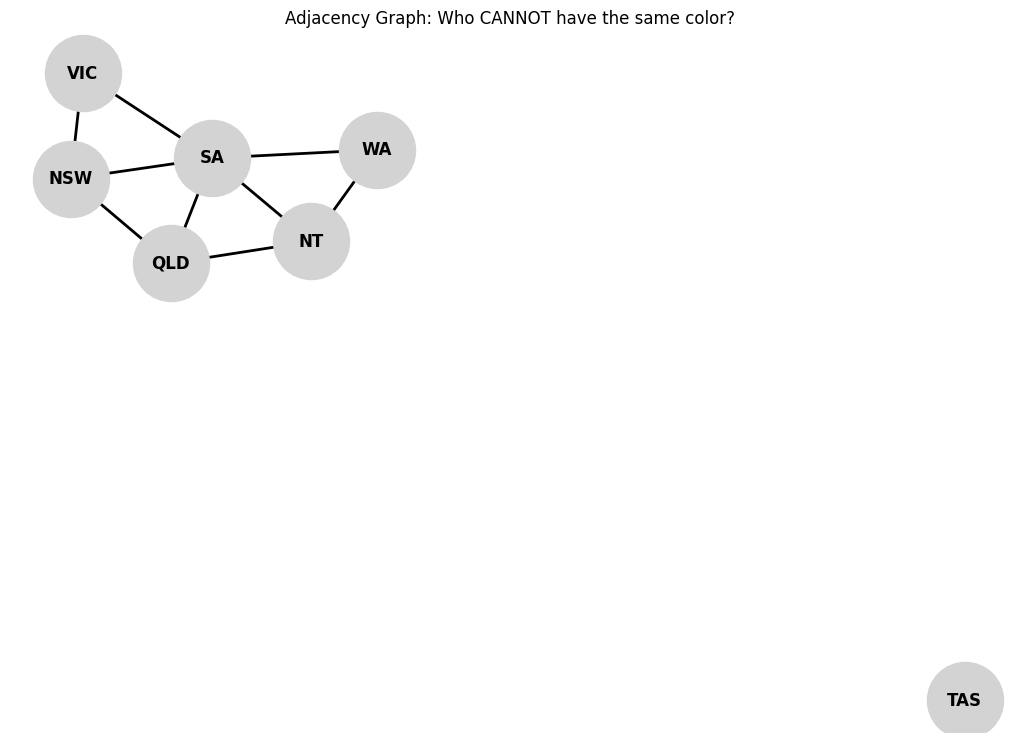

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create the Graph
G = nx.Graph()
G.add_edges_from(adjacencies)
G.add_node("TAS") # Don't forget the island!

# Plot the Graph
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42) # Consistent layout

# Draw the 'Rules'
nx.draw(G, pos, with_labels=True, 
        node_color='lightgray', node_size=3000, 
        font_size=12, font_weight='bold', 
        edge_color='black', width=2)

plt.title("Adjacency Graph: Who CANNOT have the same color?")
plt.show()

Tasmania (TAS) is an island and therefore has 0 edges connected to it.

**Solving the CSP**

Defining the problem, adding variables, and their domains and the constraints.

In [6]:
from constraint import Problem

# Initialize the CSP
problem = Problem()

# Define variables and their possible values
regions = ['WA', 'NT', 'SA', 'QLD', 'NSW', 'VIC', 'TAS']
colors = ['Red', 'Green', 'Blue']
problem.addVariables(regions, colors)

# Define the "Not Equal" constraints based on our adjacency list
adjacencies = [
    ("WA", "NT"), ("WA", "SA"),
    ("NT", "SA"), ("NT", "QLD"),
    ("SA", "QLD"), ("SA", "NSW"), ("SA", "VIC"),
    ("QLD", "NSW"),
    ("NSW", "VIC")
]

for region_1, region_2 in adjacencies:
    problem.addConstraint(lambda a, b: a != b, (region_1, region_2))

# Solve the problem
solution = problem.getSolution()
print("Constraint Solution:", solution)

Constraint Solution: {'SA': 'Blue', 'NSW': 'Green', 'QLD': 'Red', 'NT': 'Green', 'VIC': 'Red', 'WA': 'Red', 'TAS': 'Blue'}


**Visualizing it on the real map**

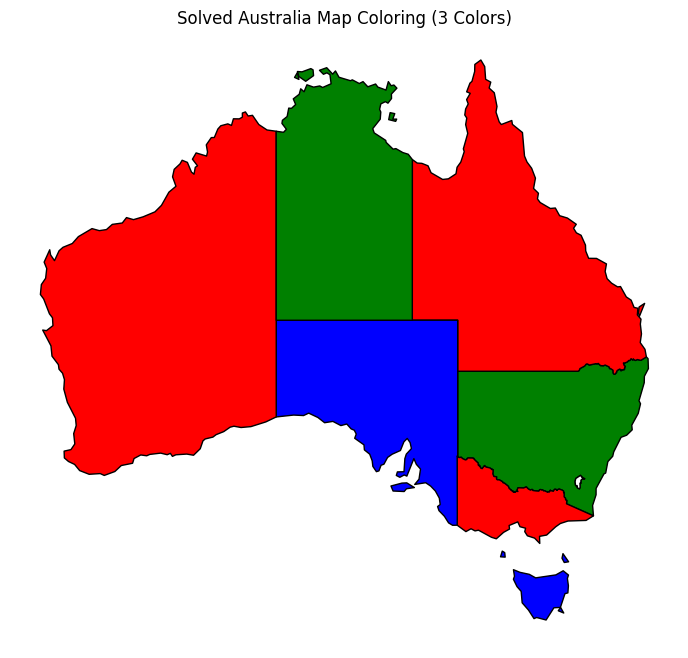

In [7]:
# Map the solution colors to the GeoDataFrame
# Note: Ensure the 'STATE_NAME' matches the keys in the solution map
name_to_short = {
    'Western Australia': 'WA', 'Northern Territory': 'NT', 
    'South Australia': 'SA', 'Queensland': 'QLD', 
    'New South Wales': 'NSW', 'Victoria': 'VIC', 'Tasmania': 'TAS'
}

# Add a 'color' column to our GeoDataFrame based on the solution
australia_states['assigned_color'] = australia_states['STATE_NAME'].map(
    lambda x: solution.get(name_to_short.get(x, ''), 'white')
)

# Plot the final colored map
fig, ax = plt.subplots(figsize=(10, 8))
australia_states.plot(ax=ax, color=australia_states['assigned_color'], edgecolor='black')

plt.title("Solved Australia Map Coloring (3 Colors)")
ax.set_axis_off()
plt.show()

# Nairobi Sub-counties

Nairobi has 17 sub-counties. The web of contraints is much larger here.

- Variables - 17 sub-counties

Lets start by defining the adjacency map.

In [ ]:

    
subcounties = [
    ("Westlands", "Dagoretti North"), ("Westlands", "Roysambu"), ("Westlands", "Kasarani"),
    ("Westlands", "Lavington"), ("Westlands", "Starehe"),
    ("Starehe", "Mathare"), ("Starehe", "Kamukunji"), ("Starehe", "Makadara"),
    ("Starehe", "Westlands"), ("Starehe", "Kasarani"), ("Starehe", "Ruaraka"),
    ("Mathare", "Starehe"), ("Mathare", "Ruaraka"), ("Mathare", "Kamukunji"),
    ("Kamukunji", "Starehe"), ("Kamukunji", "Mathare"), ("Kamukunji", "Makadara"), ("Kamukunji", "Embakasi West"),
    ("Kibra", "Lang'ata"), ("Kibra", "Dagoretti South"), ("Kibra", "Dagoretti North"),
    ("Dagoretti North", "Westlands"), ("Dagoretti North", "Dagoretti South"), ("Dagoretti North", "Kibra"),
    ("Embakasi South", "Makadara"), ("Embakasi South", "Embakasi East"), ("Embakasi South", "Lang'ata"),
    ("Roysambu", "Kasarani"), ("Roysambu", "Ruaraka"), ("Roysambu", "Westlands")
    
]

**Defining the constraints**

In [ ]:
from constraint import Problem
problem = Problem()
colors = ["Red", "Green", "Blue", "Yellow"]
problem.addVariables(sub_counties, colors)

for sub1, sub2 in nairobi_adjacencies:
    if sub1 in sub_counties and sub2 in sub_counties:
        problem.addConstraint(lambda a, b: a != b, (sub1, sub2))

solution = problem.getSolution()

**Visualizing the map**


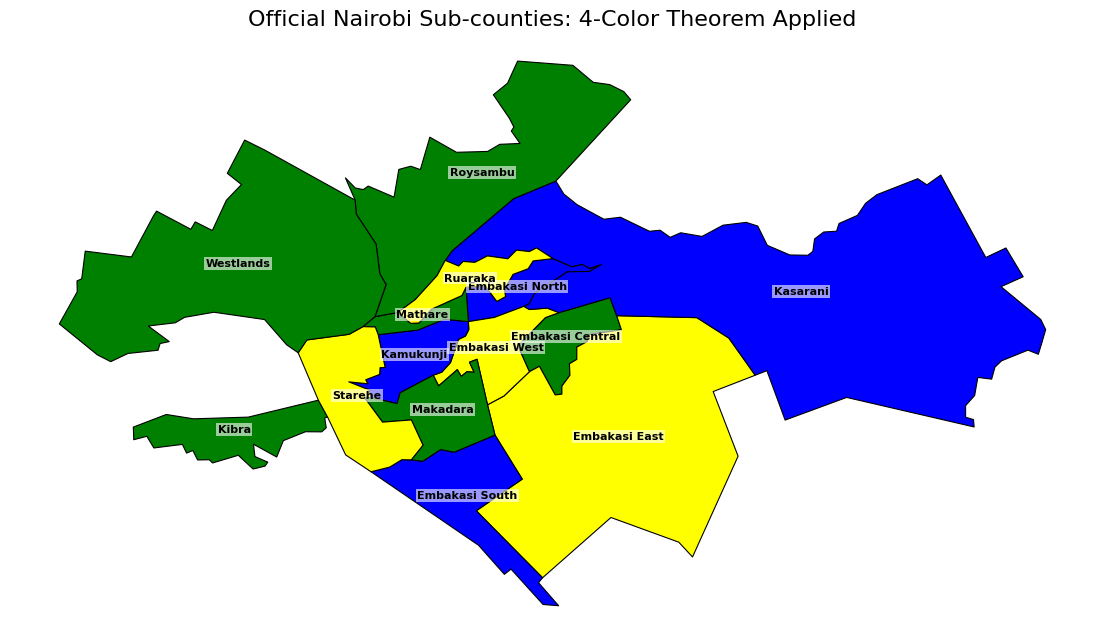

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. DOWNLOAD THE OFFICIAL MAP DATA
# This is the global open database of political administrative boundaries
print("Downloading official Nairobi sub-county boundaries...")
url = "https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/KEN/ADM2/geoBoundaries-KEN-ADM2_simplified.geojson"

# Load the GeoJSON directly into a GeoDataFrame
kenya_gdf = gpd.read_file(url)

# 2. FILTER FOR NAIROBI DISTRICTS
# The official 'shapeName' column contains the sub-county names
# We'll filter the whole country down to just our 17 Nairobi sub-counties
nairobi_names = [
    "Westlands", "Dagoretti North", "Dagoretti South", "Lang'ata", "Kibra",
    "Roysambu", "Kasarani", "Ruaraka", "Embakasi South", "Embakasi North",
    "Embakasi Central", "Embakasi East", "Embakasi West", "Makadara",
    "Kamukunji", "Starehe", "Mathare"
]

# We use a case-insensitive match to be safe
nairobi_gdf = kenya_gdf[kenya_gdf['shapeName'].str.contains('|'.join(nairobi_names), case=False)].copy()

# 3. APPLY YOUR SOLUTION
# Map your 'solution' dictionary to the real shapes
# We clean the names in the data to match your keys
nairobi_gdf['clean_name'] = nairobi_gdf['shapeName'].str.replace(' Sub County', '').str.strip()
nairobi_gdf['color'] = nairobi_gdf['clean_name'].map(solution)

# 4. PLOT THE REAL MAP
fig, ax = plt.subplots(figsize=(14, 12))
nairobi_gdf.plot(ax=ax, color=nairobi_gdf['color'], edgecolor='black', linewidth=0.8)

# Add Labels at the center of each real polygon
for idx, row in nairobi_gdf.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['clean_name'], 
            fontsize=8, ha='center', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("Official Nairobi Sub-counties: 4-Color Theorem Applied", fontsize=16)
ax.set_axis_off()
plt.show()